In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline  

import yaml

In [3]:
from library.utils import watts_to_dbm, dBm2Watts, df_float_formatter, get_NO_OF_CABLES,get_MUX_RATIO  

# Get Configuration Parameters

In [4]:
config_name = pathlib.Path.cwd().name # experiment name based on current directory

for file in pathlib.Path(CURRENT_DIR).iterdir():
    if file.suffix == ".yaml":
        config_file = pathlib.Path(file)

# Get configuration parameters for dilution fridge, cables, attenuators, components
from library.utils import load_config
config = load_config(config_file)


FRIDGE_NAME = config["FRIDGE_NAME"] 

QUBIT_FREQ     = config["QUBIT_FREQ"]
QUBIT_COUPLING = config["QUBIT_COUPLING"]

QUBIT_TYPES = config["QUBIT_TYPES"]

OPERATIONS = config["OPERATIONS"]
READOUT_GROUP_SIZE = config["READOUT_GROUP_SIZE"]
DRIVE_MUX   = config["DRIVE_MUX"]
READIN_MUX   = config["READIN_MUX"]
MXC_POWER_SCHEME = config["MXC_POWER_SCHEME"]
WORKLOAD_TYPE = config["WORKLOAD_TYPE"]

CABLE_TYPES = config["CABLE_TYPES"]
CABLE_CONFIG_NAMES = config["CABLE_CONFIG_NAMES"]  
ATT_CONFIG = config["ATT_CONFIG"]  
COMP_CONFIG_NAMES = config["COMP_CONFIG_NAMES"]  
ACTIVATION_MATRIX = config["ACTIVATION_MATRIX"] 

if "DC_PARAMS" in config.keys():
    DC_PARAMS = config["DC_PARAMS"]
    R_4K = DC_PARAMS["R_4K"] 
    R_Still = DC_PARAMS["R_Still"] 
    R_CP = DC_PARAMS["R_CP"] 
    R_MXC = DC_PARAMS["R_MXC"]  
    I_BIAS = DC_PARAMS["I_BIAS"]  
    I_2Q = DC_PARAMS["I_2Q"] #NREQ
else:
    R_4K = None
    R_Still = None
    R_CP = None
    R_MXC = None
    I_BIAS = None
    I_2Q = None

# Get Workload Specifications

In [5]:
from library.workload_specs import WORKLOADS_DICT
from library.mxc_powers import MXC_POWERS_DICT

WORKLOAD = WORKLOADS_DICT[WORKLOAD_TYPE]
MXC_POWER = MXC_POWERS_DICT[MXC_POWER_SCHEME]

In [6]:
# Latency of Operations
LATENCY = WORKLOAD["LATENCY"]

# Number of Operations
OPERATION_COUNTS = WORKLOAD["OPERATION_COUNT"]

# Mulitplexing Ratio
MUX_RATIO = get_MUX_RATIO(OPERATIONS, DRIVE_MUX, READIN_MUX, READOUT_GROUP_SIZE)

In [7]:
# Sanity check for ACTIVATION MATRIX
from library.utils import check_activation_matrix
check_activation_matrix(ACTIVATION_MATRIX, OPERATIONS);

# Get dilution refrigerator parameters

In [8]:
from library.fridges import TEMP_STAGES, FRIDGE_LIBRARY
fridge = FRIDGE_LIBRARY[FRIDGE_NAME]
cooling_power_budget = fridge["cooling_power"]
operating_temp = fridge["temp"]
flange_separation = fridge["lengths"]

In [9]:
# Create a summary of the fridge/cable/attenuator configuration
NO_OF_CABLES = get_NO_OF_CABLES(QUBIT_TYPES, QUBIT_FREQ, QUBIT_COUPLING, READOUT_GROUP_SIZE)

In [10]:
# Create a dictionary with cable classes instantiated
from library.cables import get_cable_config
CABLE_CONFIG = get_cable_config(CABLE_CONFIG_NAMES)

In [11]:
# Create a dictionary with component  classes instantiated
from library.components import get_comp_config
COMP_CONFIG = get_comp_config(COMP_CONFIG_NAMES)

In [12]:
# Add ohmic resistors
from library.components import add_ohmic_resistors_amp_at_4K,add_ohmic_resistors_amp_at_50K, add_flux_coupler_DC_resistance

# update COMP_CONFIG with ohmic resistors at 4K and 50K for amplifier at 4K
COMP_CONFIG = add_ohmic_resistors_amp_at_4K(CABLE_CONFIG_NAMES, COMP_CONFIG, fridge)
# update COMP_CONFIG with ohmic resistors at 50K for amplifier at 50K
if 'AMP_BIAS_50K' in CABLE_CONFIG_NAMES.keys():
    COMP_CONFIG = add_ohmic_resistors_amp_at_50K(CABLE_CONFIG_NAMES, COMP_CONFIG, fridge)

In [13]:
# update COMP_CONFIG with DC resistors for flux/coupler-bias lines
COMP_CONFIG = add_flux_coupler_DC_resistance(COMP_CONFIG,
                                           QUBIT_FREQ, 
                                           QUBIT_COUPLING, 
                                           R_4K, R_Still, R_CP, R_MXC,
                                           I_BIAS, I_2Q)

# Passive Heat Load (PHL) Calculation

In [14]:
from collections import defaultdict
PHL = defaultdict(lambda: defaultdict(dict)) # Passive Heat Load Dictionary
# PHL[cable_type][temp_stage] = total PHL due to that cable_type
for cable_type in CABLE_TYPES:
    for temp_stage in TEMP_STAGES:
        cable_heat_load = 0.0
        if CABLE_CONFIG[cable_type][temp_stage] is not None:
            if CABLE_CONFIG[cable_type][temp_stage].PHL_dict[temp_stage] is not None:

                # get cable length
                cable_length = flange_separation[temp_stage]

                # get thermal gradient
                current_temp_stage_idx = TEMP_STAGES.index(temp_stage)
                if current_temp_stage_idx > 0:
                    prev_temp_stage = TEMP_STAGES[current_temp_stage_idx - 1]

                T_lo = operating_temp[temp_stage]
                T_hi = operating_temp[prev_temp_stage]
                temp_diff = T_hi - T_lo

                # calculate PHL
                cable_heat_load = CABLE_CONFIG[cable_type][temp_stage].get_PHL(temp_stage, cable_length, T_lo, T_hi) * NO_OF_CABLES[cable_type]

        PHL[cable_type][temp_stage] = cable_heat_load    

# Active Heat Load (AHL) Calculation

- The heat load arises either from components at the stage or due to attenuators on that stage
- However, attenuators dissipate heat only when the cable is active i.e., the duty cycle of the operation being performed using the cable affects the heat dissipated.
- Some components (amplifiers and their respective ohmic resistances) are always ON and dissipate heat at all times
- Some components (ohmic resistance for coupler qubits) dissipate heat depending on the operation

## AHL from Attenuator Dissipation

In [15]:
from library.cables import cable_attenuator_dissipation

ATT_DISSIPATION = defaultdict(lambda: defaultdict(dict))
for cable_type in CABLE_TYPES:
    # Get the attenuator configuration for the cable
    cable_attenuator_config = ATT_CONFIG[cable_type]
    # Calculate power dissipation for each type of operation
    # This is the power dissipation for a SINGLE cable
    # Power dissipation in is dBm and assumes 100% duty cycle
    # This is NOT the final power dissipation by the attenuators
    for operation in OPERATIONS:
        ATT_DISSIPATION[cable_type][operation] = cable_attenuator_dissipation(cable_attenuator_config, MXC_POWER[cable_type][operation])

# Total Heat Load (THL)

In [16]:
THL = defaultdict(lambda: defaultdict(dict))

for cable_type in CABLE_TYPES:
    for temp_stage in TEMP_STAGES:
        
        # components in each cable at each temperature stage
        component_list = COMP_CONFIG[cable_type][temp_stage]
        if component_list is not None:
                for component in component_list:
                        THL[cable_type][temp_stage][component.name]={}
        # Add key for attenuator component
        THL[cable_type][temp_stage]["ATT"]={}

        # Include passive heat load
        THL[cable_type][temp_stage]["PASSIVE"]={}
        THL[cable_type][temp_stage]["PASSIVE"]["IDLE"] = PHL[cable_type][temp_stage]
                            
        for operation in OPERATIONS:
            # Some cable operations (e.g., Readout) are multiplexed. 
            # So the actual no. of cable activations required is only a fraction of the total required number of operations
            # This fraction is the MUX_RATIO for that operation
            # effective_no_of_ops represents the total number of times a particular cable is activated in totality 
            # (regardless of how many cables are present)
            # In other words, if we assume there was only one cable of a certain type, effective_no_of_ops represents how
            # many times it is activated
            # For e.g., assuming there are 8 DRIVE cables and each cable is activated 3 times for a 1Q operation.
            # This is equivalent to 1 DRIVE cable being activated 8*3=24 times for 1Q gates.
            effective_no_of_ops = MUX_RATIO[operation] * OPERATION_COUNTS[operation]
            # Operations are active for only a fraction of the total code cycle duration
            # This duty cycle is taken into consideration by `operation_active_fraction`
            operation_active_fraction = effective_no_of_ops  * LATENCY[operation]/LATENCY["TOTAL"]

            # Active Load from Attenuators: convert to Watts
            attn_dissipation = dBm2Watts(ATT_DISSIPATION[cable_type][operation][temp_stage])
            THL[cable_type][temp_stage]["ATT"][operation] = attn_dissipation * operation_active_fraction
            # NOTE: This value DOES NOT need to be mulitplied with NO_OF_CABLES[cable_type] because it is already considered
            # during the calculation of effective_no_of_ops

            # Active Load from components
            if component_list is not None:
                for component in component_list:
                    if operation in ACTIVATION_MATRIX[cable_type]:
                        if operation != "IDLE":
                            component_power = component.power_dissipation(operation, MXC_POWER) * operation_active_fraction
                            # NOTE: This value DOES NOT need to be mulitplied with NO_OF_CABLES[cable_type] because it is already considered
                            # during the calculation of effective_no_of_ops
                            THL[cable_type][temp_stage][component.name][operation] = component_power
                        elif operation == "IDLE":
                            no_of_components = NO_OF_CABLES[cable_type]
                            component_power = component.power_dissipation(operation, MXC_POWER) * no_of_components
                            # NOTE: This value MUST BE mulitplied with NO_OF_CABLES[cable_type] because the component is always ON
                            # and scales with the number of components
                            THL[cable_type][temp_stage][component.name][operation] = component_power

### Redirecting TWPA Power Dissipation from MXC to 4K
The 20dB attenuation at MXC is achieved via circulator. This power can be redirected to the 4K stage for dissipation

In [17]:
# Redirecting TWPA Power Dissipation from MXC to 4K
THL['PUMP']['4K']['ATT']['READOUT'] = THL['PUMP']['4K']['ATT']['READOUT'] + THL['PUMP']['MXC']['ATT']['READOUT'] 
THL['PUMP']['MXC']['ATT']['READOUT'] = 0.0 

In [18]:
# Visualizing Active Heat Load as table
# This is the heat load for one 8-qubit cell

rows = []
for cable_type, temp_dict in THL.items():
    for temp_stage, comp_dict in temp_dict.items():
        for comp, operation_dict in comp_dict.items():
            for operation, power in operation_dict.items():
                rows.append((cable_type, comp, operation, temp_stage, power))
    
# Create DataFrame
df = pd.DataFrame(rows, columns=["Cable", "Component", "Operation", "Temp", "Power"])
            
# Pivot into desired table
table = df.pivot_table(
    index=["Cable", "Component", "Operation"], 
    columns="Temp", 
    values="Power"
)
THL_DF = table.fillna(0)


desired_cols = ["50K","4K", "Still", "CP", "MXC"]
THL_DF = THL_DF.reindex(columns=desired_cols)


# Get the order in which to rearrange the rows
from library.constants import ORDER_DICT

# Rearrange rows
rows = THL_DF.index.get_level_values("Cable").unique().tolist()
reordered_rows = sorted(rows, key=lambda x: ORDER_DICT[x])
THL_DF = THL_DF.reindex(reordered_rows, level=0)

# Drop rows where *every* entry is NaN, 0 or 0.0
mask = ~(THL_DF == 0).all(axis=1)
THL_DF = THL_DF[mask]

THL_DF.style.format(df_float_formatter)

In [19]:
# Calculate how many qubits are supported at each temperature stage
from library.utils import get_pq_dict
QUBIT_GROUP_SIZE = QUBIT_TYPES["DATA"] + QUBIT_TYPES["ANCILLA"]
physical_qubits_dict = get_pq_dict(THL_DF, cooling_power_budget, QUBIT_GROUP_SIZE )

The number of qubits supported at each temperature stage is:
{'50K': 216, '4K': 232, 'Still': 4704, 'CP': 152, 'MXC': 184}

The bottleneck is at: CP
max_supported_qubits=152
{'50K': 70.17, '4K': 64.74, 'Still': 3.23, 'CP': 98.99, 'MXC': 80.34}


## Normalized Heat Load and Qubit Scaling

In [20]:
TOTAL_NO_OF_QUBITS = int(min(physical_qubits_dict.values())) # does not include the coupler qubits
NO_OF_QUBIT_GROUPS = int(min(physical_qubits_dict.values())/QUBIT_GROUP_SIZE)

findfont: Failed to find font weight light, now using 400.
findfont: Failed to find font weight light, now using 400.
findfont: Failed to find font weight light, now using 400.


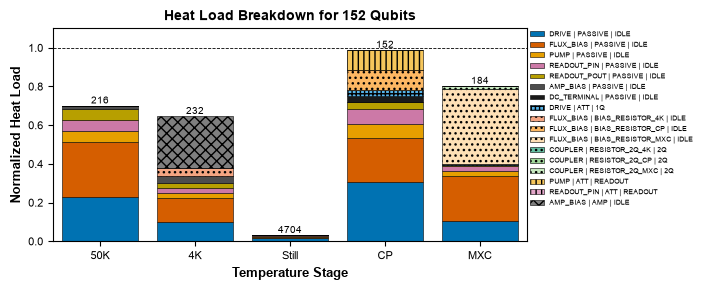

Cable         DRIVE FLUX_BIAS      PUMP READOUT_PIN READOUT_POUT AMP_BIAS  \
Component   PASSIVE   PASSIVE   PASSIVE     PASSIVE      PASSIVE  PASSIVE   
Operation      IDLE      IDLE      IDLE        IDLE         IDLE     IDLE   
Temp                                                                        
50K        0.228000  0.283733  0.057000    0.057000     0.057000    0.019   
4K         0.101333  0.121600  0.025333    0.025333     0.025333    0.038   
Still      0.015200  0.007600  0.003800    0.003800     0.000950    0.000   
CP         0.304000  0.228000  0.076000    0.076000     0.034200    0.000   
MXC        0.104000  0.232000  0.026000    0.026000     0.004000    0.000   

Cable     DC_TERMINAL     DRIVE        FLUX_BIAS                   \
Component     PASSIVE       ATT BIAS_RESISTOR_4K BIAS_RESISTOR_CP   
Operation        IDLE        1Q             IDLE             IDLE   
Temp                                                                
50K           0.00000  0.000000          0.00000         0.000000   
4K            0.00000  0.000366          0.04115         0.000000   
Still         0.00095  0.000000          0.00000         0.000000   
CP            0.03420  0.027440          0.00000         0.103708   
MXC           0.00400  0.002888          0.00000         0.000000   

Cable                              COUPLER                                 \
Component BIAS_RESISTOR_MXC RESISTOR_2Q_4K RESISTOR_2Q_CP RESISTOR_2Q_MXC   
Operation              IDLE             2Q             2Q              2Q   
Temp                                                                        
50K                 0.00000       0.000000         0.0000        0.000000   
4K                  0.00000       0.001547         0.0000        0.000000   
Still               0.00000       0.000000         0.0000        0.000000   
CP                  0.00000       0.000000         0.0039        0.000000   
MXC                 0.38988       0.000000         0.0000        0.014662   

Cable          PUMP   READOUT_PIN AMP_BIAS     Total  
Component       ATT           ATT      AMP            
Operation   READOUT       READOUT     IDLE            
Temp                                                  
50K        0.000000  0.000000e+00    0.000  0.701733  
4K         0.001367  4.318182e-09    0.266  0.647363  
Still      0.000000  0.000000e+00    0.000  0.032300  
CP         0.102415  3.238636e-07    0.000  0.989864  
MXC        0.000000  3.409091e-08    0.000  0.803430

In [21]:
# --- Normalize the DataFrame ---
# Since the temperature stages are columns, we divide each column by its normalization factor.
NHL_DF = THL_DF.copy()
for temp_stage in NHL_DF.columns:
    NHL_DF[temp_stage] = (NHL_DF[temp_stage] * NO_OF_QUBIT_GROUPS)/cooling_power_budget[temp_stage]

# --- Prepare the DataFrame for plotting ---
# We want the X-axis to be the temperature stages.
# To do so, we transpose the DataFrame so that rows become the temperature stages.
df_plot = NHL_DF.T  # now rows: temperature stages; columns: MultiIndex (Component, Subcomponent)

# Prepare the title
title = f"Heat Load Breakdown for {TOTAL_NO_OF_QUBITS} Qubits"

# Plot the dataframe
from library.utils import plot_heat_load
plot_heat_load(df_plot, title, config_name, physical_qubits_dict, legend_bbox=(1.0, 1.0))